
# metabeta — getting started

**metabeta** fits Bayesian mixed-effects models in milliseconds instead of minutes.
It uses a pre-trained neural network to approximate the posterior — no MCMC, no warmup.

This notebook walks through the full workflow on the classic `sleepstudy` dataset:
**load → sample → interpret.**


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

from metabeta.models.router import Router

mb = Router('/tmp/joint_normal_v1.pt', device='cpu')



## 1. Dataset

The `sleepstudy` dataset (`Belenky et al. 2003`) tracks reaction times (ms) for 18 subjects
across 10 days of sleep restriction — a two-level design with observations nested within
subjects. We refer to subjects as groups.


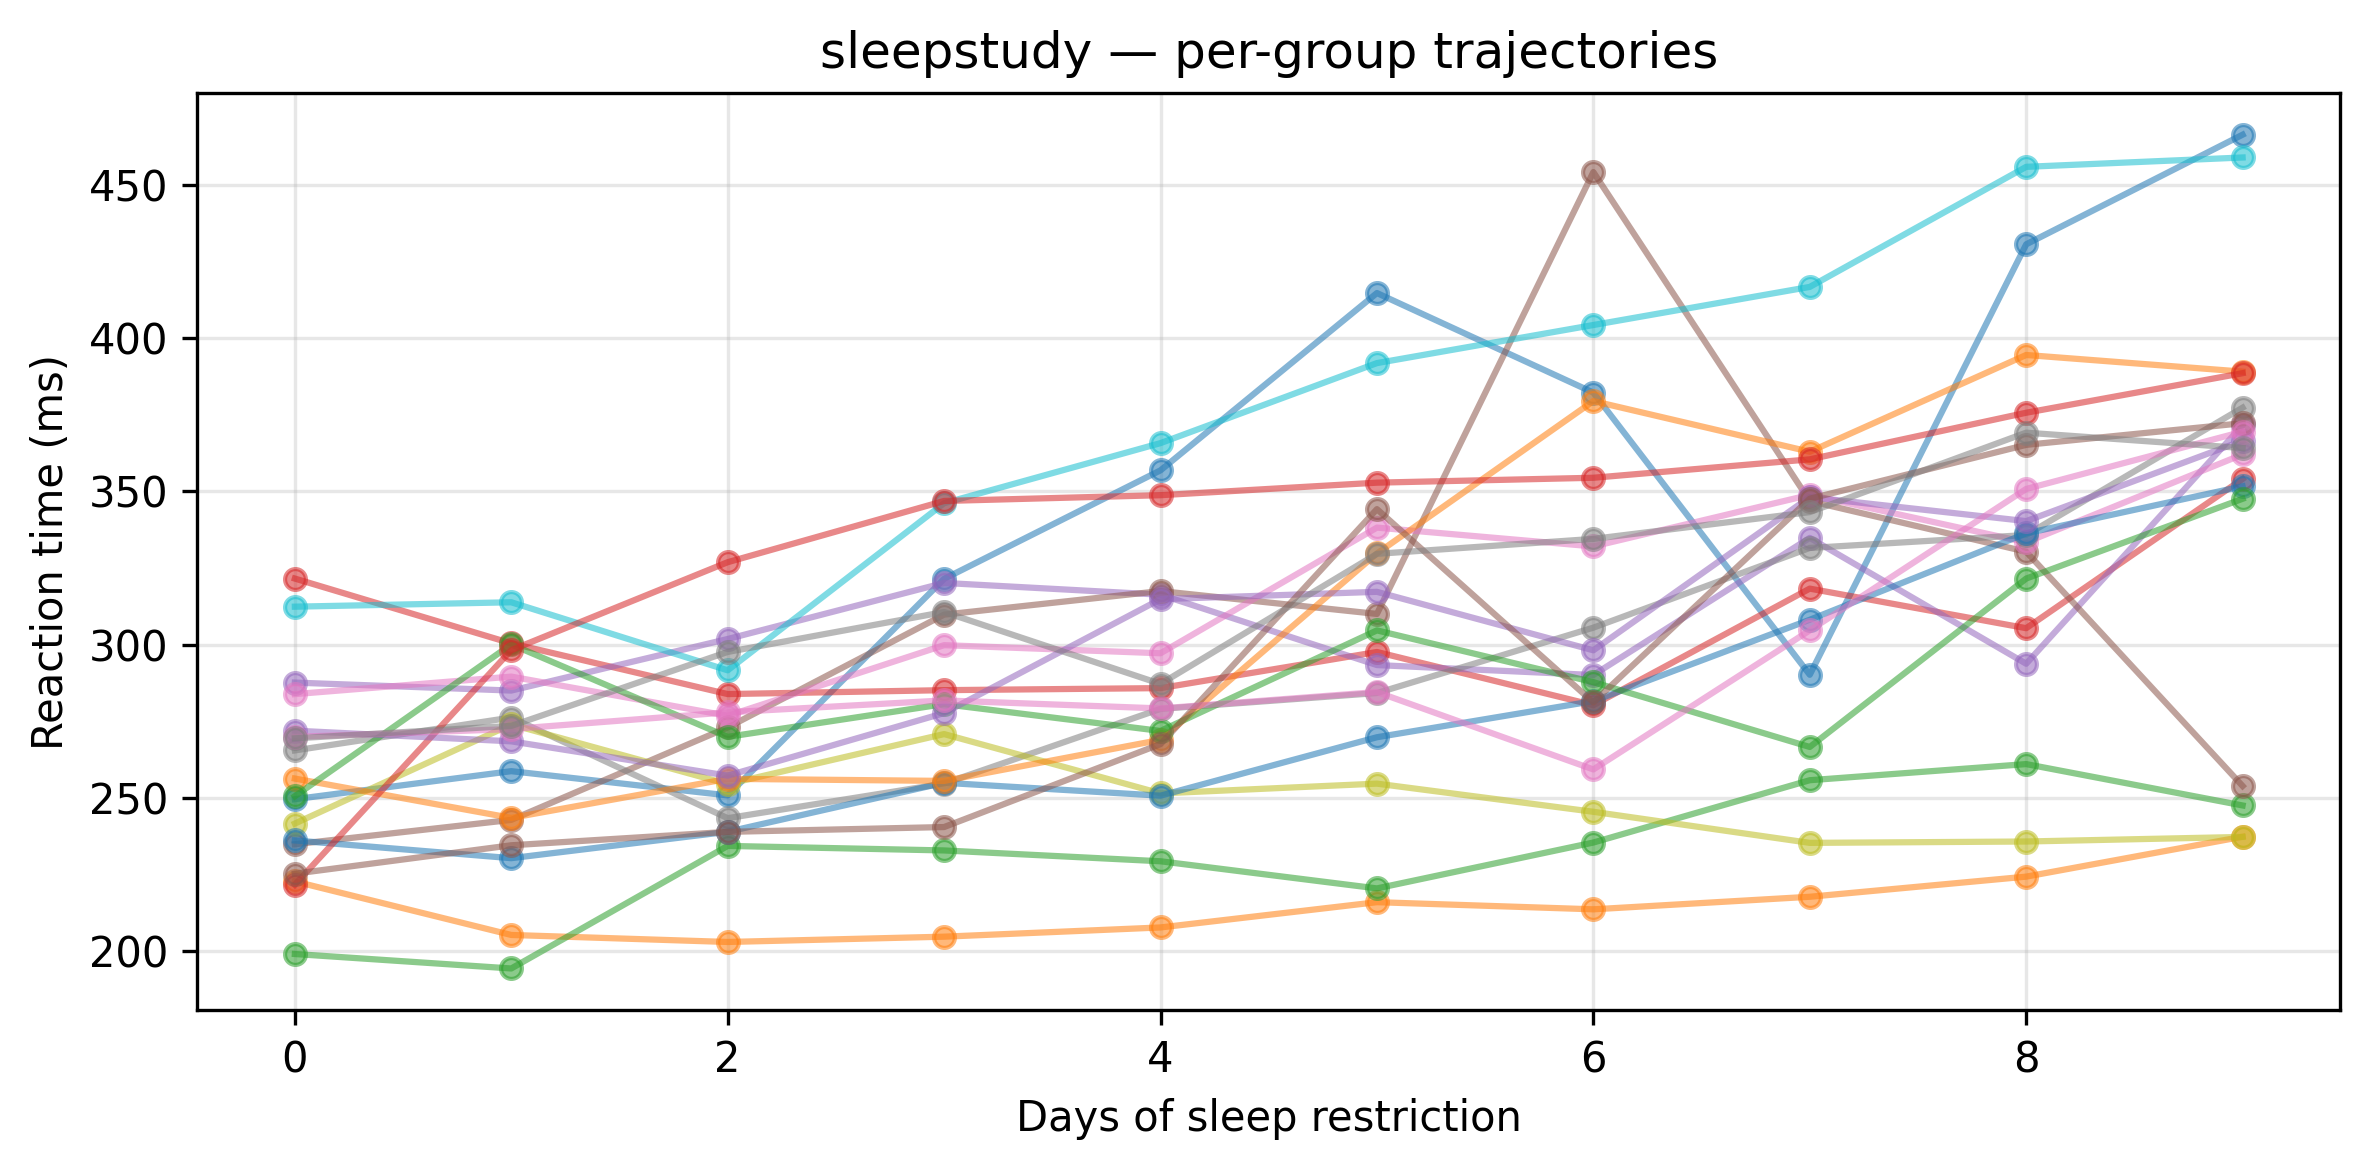

In [2]:
df = pd.read_parquet('../metabeta/datasets/from-r/parquet/sleep.parquet')

fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
for _, grp in df.groupby('group'):
    ax.plot(grp['Days'], grp['y'], 'o-', alpha=0.55, lw=1.5, ms=5)
ax.set_xlabel('Days of sleep restriction')
ax.set_ylabel('Reaction time (ms)')
ax.set_title('sleepstudy — per-group trajectories')
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()



## 2. Inference

Describe the model with a standard **lme4-style formula**: `Days` enters as a fixed slope
and each subject gets its own random intercept.
`mb.sample()` handles preprocessing internally, routes the dataset to the right submodel,
and returns 1 000 posterior draws in under a second.


In [3]:
result = mb.sample(
    df,
    formula='y ~ Days + (1 | group)',
    fit_preprocessor=True,
    n_samples=1000,
    diagnostics=True,
)



## 3. Results

All estimates are on the **original scale** of the data (ms).

| Column | Meaning |
|--------|---------|
| Mean · SD · 2.5 % · 97.5 % | Posterior mean, standard deviation, and 95 % credible interval |
| P(>0) | Posterior probability that the effect is positive |
| Contr. | Posterior contraction — 1 means fully data-driven, 0 means prior-dominated |

Fit metrics at the bottom: **R²** (variance explained), **LOO-NLL** (PSIS-based leave-one-out posterior predictive performance, `Vehtari et al. 2015`) and accompanying **Pareto k** (LOO-NLL reliability; values below 0.7 are fine).


In [4]:
print(mb.posteriorSummary(result, x_scale='original'))


Formula:  y ~ Days + (1 | group)
n = 180   m = 18
Scale:    original  (slopes: Δy per unit predictor; σ and rfx: y units)
Priors:
  Intercept ~ N(298.5, 140.4)
  days ~ N(0, 48.89)
  σ_Intercept ~ HN(140.4)
  σ_Residual ~ HT₅(56.17)

Fixed Effects:
|           |    Mean |     SD |    2.5% |   97.5% |   P(>0) |   Contr. |
|:----------|--------:|-------:|--------:|--------:|--------:|---------:|
| Intercept | 251.058 | 12.704 | 226.032 | 275.858 |   1.000 |    0.992 |
| days      |  10.489 |  1.642 |   6.984 |  13.545 |   1.000 |    0.999 |

Standard Deviations (y units):
|           |   Mean |    SD |   2.5% |   97.5% |
|:----------|-------:|------:|-------:|--------:|
| Intercept | 40.097 | 8.233 | 27.189 |  59.046 |
| Residual  | 31.220 | 1.797 | 27.721 |  34.953 |

draws = 1000   R² = 0.726   LOO-NLL = 0.913   Pareto k = 0.228



### Per-subject random effects

Each group's baseline reaction time deviation from the population intercept, in ms.
**z** is the posterior mean divided by σ_Intercept — how many between-subject SDs that
group is from average. Most groups should have |z| < 2; larger values flag unusual groups.
**SD ratio** is the ratio between the empirical SD of RFX and the estimated σ.


In [5]:
print(mb.rfxSummary(result))


Random Effects:
Scale:    original y units  (intercept deviations from population intercept β₀)
|   Group |   n |   Intercept Mean |   Intercept 2.5% |   Intercept 97.5% |   Intercept z |
|---------|-----|------------------|------------------|-------------------|---------------|
|     308 |  10 |           41.610 |           14.324 |            69.264 |          1.04 |
|     309 |  10 |          -77.893 |         -105.672 |           -53.326 |         -1.94 |
|     310 |  10 |          -62.721 |          -89.426 |           -37.409 |         -1.56 |
|     330 |  10 |            4.282 |          -22.222 |            31.333 |          0.11 |
|     331 |  10 |           10.424 |          -16.525 |            38.433 |          0.26 |
|     332 |  10 |            8.020 |          -18.234 |            34.614 |          0.20 |
|     333 |  10 |           16.376 |          -11.126 |            44.020 |          0.41 |
|     334 |  10 |           -2.762 |          -30.181 |            23.942 | 

## 4. Posterior distributions

The pair grid below shows the joint posterior over all global parameters — intercept,
Days slope, between-subject SD (σ_Intercept), and residual SD (σ_ε).

- **Diagonal** — marginal posterior (green) with the **prior** (blue) overlaid. A narrow
  posterior relative to its prior means the data were informative for that parameter.
- **Upper triangle** — posterior scatter.
- **Lower triangle** — posterior density contours.


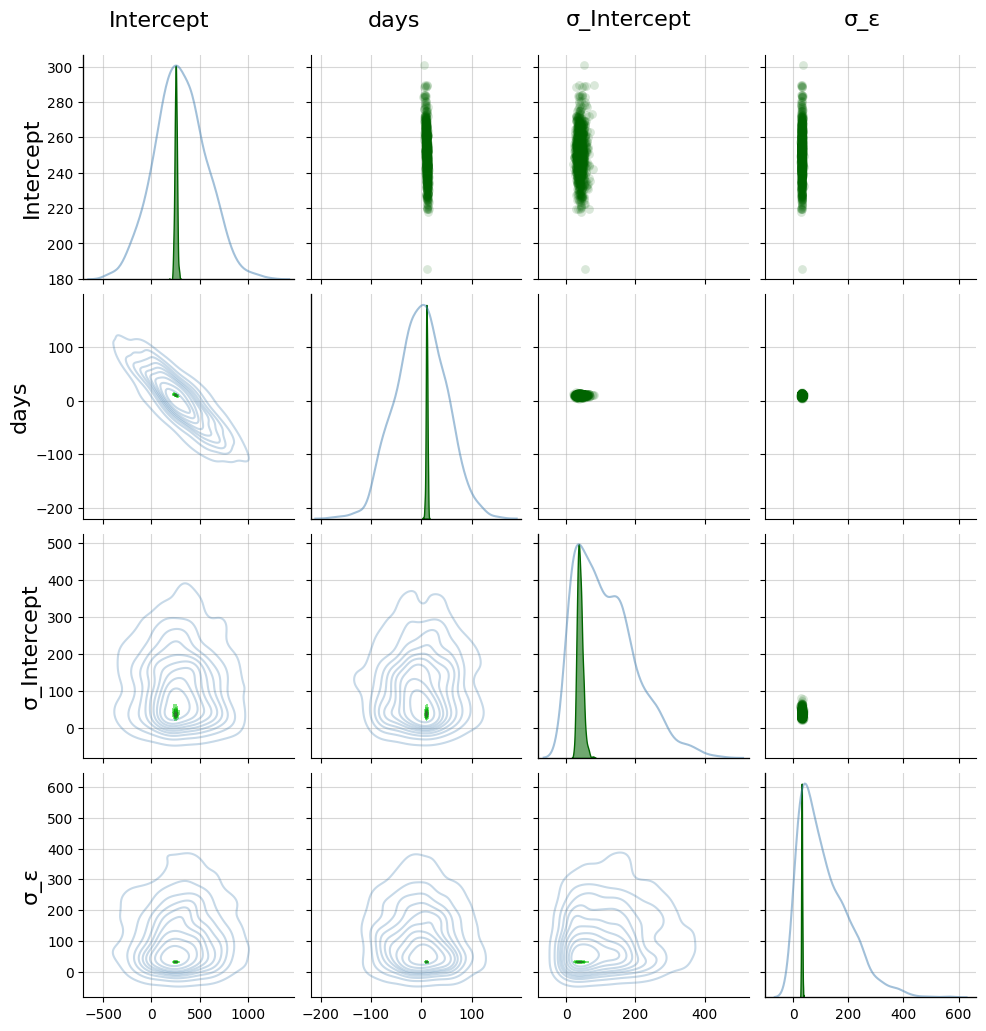

In [6]:
mb.plotParameters(result);
